In [1]:
pip install datasets

Defaulting to user installation because normal site-packages is not writeable
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.2/69.2 kB 861.9 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 1.0 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 1.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 456.0/456.0 kB 1.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 1.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 2.2 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 13.7 MB/s eta 0:00:0000:0100:01
Using cached requests-2.32.3-py3-none-any.whl (64 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.3 MB/s e

In [3]:
from datasets import load_dataset

dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Books", split="full", trust_remote_code=True)

Books.jsonl:   0%|          | 0.00/20.1G [00:00<?, ?B/s]

Generating full split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/33 [00:00<?, ?it/s]

In [4]:
# distribution of rating
print(dataset.info)

DatasetInfo(description='Amazon Review 2023 is an updated version of the Amazon Review 2018 dataset.\nThis dataset mainly includes reviews (ratings, text) and item metadata (desc-\nriptions, category information, price, brand, and images). Compared to the pre-\nvious versions, the 2023 version features larger size, newer reviews (up to Sep\n2023), richer and cleaner meta data, and finer-grained timestamps (from day to \nmilli-second).\n\nThis is a subset for reviews in domain: Books.', citation='', homepage='', license='', features={'rating': Value(dtype='float64', id=None), 'title': Value(dtype='string', id=None), 'text': Value(dtype='string', id=None), 'images': [{'attachment_type': Value(dtype='string', id=None), 'large_image_url': Value(dtype='string', id=None), 'medium_image_url': Value(dtype='string', id=None), 'small_image_url': Value(dtype='string', id=None)}], 'asin': Value(dtype='string', id=None), 'parent_asin': Value(dtype='string', id=None), 'user_id': Value(dtype='string'

In [5]:
# first 1 million reviews
sample_dataset = dataset.take(1_000_000)

In [6]:
ratings = [sample_dataset[i]['rating'] for i in range(1_000_000)]

In [7]:
import matplotlib.pyplot as plt
import numpy as np

labels, counts = np.unique(np.array(ratings), return_counts=True)
print(labels, counts)

[0. 1. 2. 3. 4. 5.] [     4  33952  35812  79114 170464 680654]


It looks like there are 4 instances where the rating is 0, they must be some error while scrapping the reviews as 1 star is the minimum that you can give in Amazon.

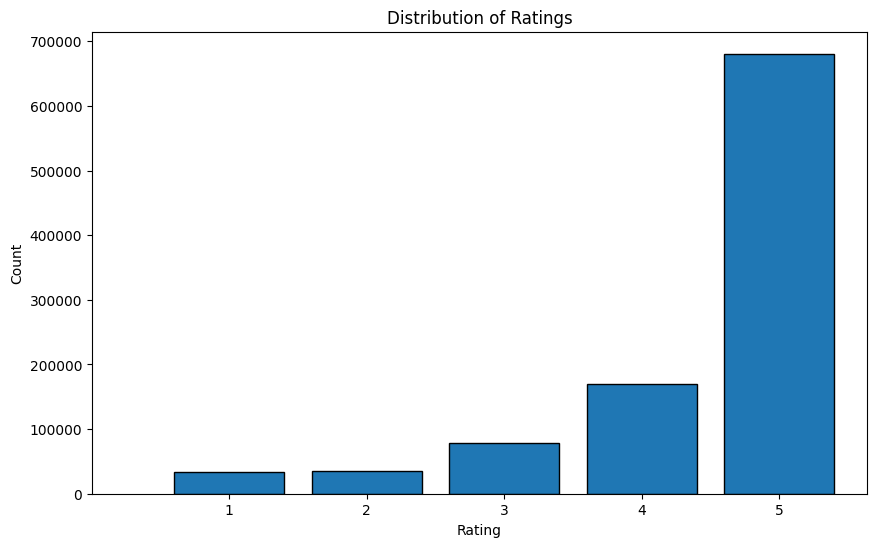

In [8]:
plt.figure(figsize=(10,6))
plt.bar(labels[1:], counts[1:], align='center', edgecolor='black')
plt.gca().set_xticks(labels)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Ratings')
plt.xticks(np.arange(1, 6))
plt.savefig('distribution_of_ratings.svg', format='svg')
plt.show()

In [9]:
# rating vs length of review - does books with higher rating have longer reviews
rating_vs_review_length = {}
review_length = [len(sample_dataset[i]['text']) for i in range(len(sample_dataset))]

In [10]:
for key, value in zip(ratings, review_length):
  rating_vs_review_length.setdefault(key, []).append(value)

In [11]:
del rating_vs_review_length[0]

In [12]:
rating_vs_review_length = dict(sorted(rating_vs_review_length.items()))
rating_vs_review_length.keys()

dict_keys([1.0, 2.0, 3.0, 4.0, 5.0])

In [16]:
import matplotlib
matplotlib.__version__

'3.8.0'

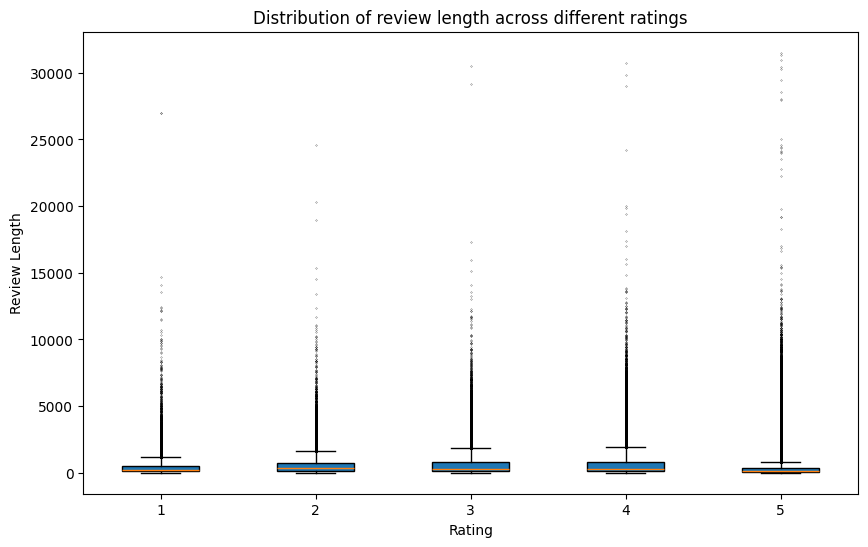

In [20]:

# Create the boxplot
fig, ax = plt.subplots(figsize=(10,6))
ax.boxplot(rating_vs_review_length.values(),
           #tick_labels=rating_vs_review_length.keys(),
           showfliers=True,
           patch_artist=True,
           flierprops={'markersize': 0.2})

# Customize the plot

ax.set_title('Distribution of review length across different ratings')
ax.set_ylabel('Review Length')
ax.set_xlabel('Rating')
plt.xticks(list(rating_vs_review_length.keys()))
plt.savefig('ratings_vs_review_length_with_outliers.svg', format='svg')
plt.show()

# Are those reviews outliers? Here is how the plot looks if we do not consider the outliers. The median length of a 5 star review is less than the rest.

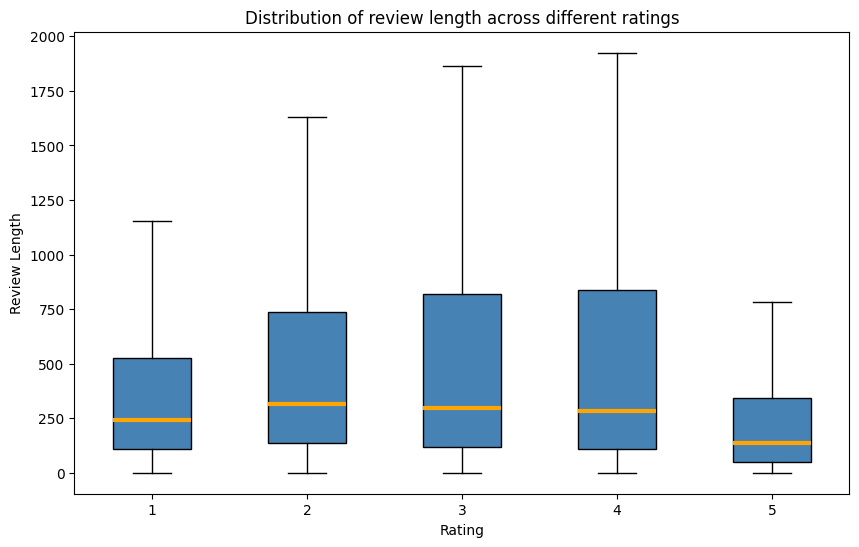

In [21]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(10,6))
boxprops = dict(facecolor='steelblue', edgecolor='black')
ax.boxplot(rating_vs_review_length.values(),
           #tick_labels=rating_vs_review_length.keys(),
           showfliers=False,
           patch_artist=True,
           boxprops=boxprops,
           medianprops={'linewidth': 3, 'color':'orange'})

# Customize the plot
ax.set_title('Distribution of review length across different ratings')
ax.set_ylabel('Review Length')
ax.set_xlabel('Rating')
plt.xticks(list(rating_vs_review_length.keys()))
plt.savefig('ratings_vs_review_length.svg', format='svg')
plt.show()

In [22]:
sample_dataset.to_csv("sample_books_dataset.csv")

Creating CSV from Arrow format:   0%|          | 0/1000 [00:00<?, ?ba/s]

561806633

In [23]:
sample_dataset[43]

{'rating': 5.0,
 'title': 'What rock have I been under?',
 'text': "I've seen all the Hell Raiser movies but some how I never that movies where novels! I just so happened to come across this book and man oh man! It didn't disappoint. This is one of the few novels I've actually finished and I can't wait to start the next one.",
 'images': [],
 'asin': 'B000FC124G',
 'parent_asin': 'B000FC124G',
 'user_id': 'AFJTRBXMURLHS5EGNXLUHDHIZRFQ',
 'timestamp': 1655096356252,
 'helpful_vote': 2,
 'verified_purchase': True}

- Distribution of ratings/reviews for each book
  - Across categories of books
- Distribution of helpful votes
- How does number of reviews/average rating change over time?

In [24]:
helpful_votes = [sample_dataset[i]['helpful_vote'] for i in range(len(sample_dataset))]

In [25]:
counts, bins = np.histogram(helpful_votes, bins=25)
print(np.rint(bins))
print(counts)

[-5.000e+00  2.320e+02  4.690e+02  7.060e+02  9.430e+02  1.180e+03
  1.417e+03  1.654e+03  1.891e+03  2.128e+03  2.365e+03  2.602e+03
  2.839e+03  3.075e+03  3.312e+03  3.549e+03  3.786e+03  4.023e+03
  4.260e+03  4.497e+03  4.734e+03  4.971e+03  5.208e+03  5.445e+03
  5.682e+03  5.919e+03]
[999612    264     55     31     15      7      2      2      1      2
      1      2      0      0      1      2      0      0      1      0
      1      0      0      0      1]


{'whiskers': [<matplotlib.lines.Line2D at 0x314324640>,
 'caps': [<matplotlib.lines.Line2D at 0x314324b80>,
 'boxes': [<matplotlib.patches.PathPatch at 0x314324280>],
 'medians': [<matplotlib.lines.Line2D at 0x314330100>],
 'fliers': [],
 'means': []}

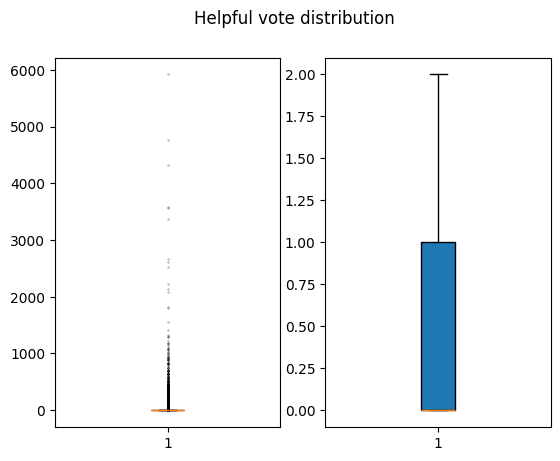

In [26]:
import seaborn as sns

# Create the histogram
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Helpful vote distribution')
ax1.boxplot(helpful_votes, flierprops={'markersize': 0.2}, patch_artist=True)
ax2.boxplot(helpful_votes, showfliers=False, patch_artist=True)

In [27]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.3.1 -> 24.3.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
from wordcloud import WordCloud, STOPWORDS

In [29]:
all_titles = [sample_dataset[i]['title'] for i in range(len(sample_dataset))]
text = ' '.join(all_titles)

In [30]:
stopwords = set(STOPWORDS)
stopwords.update(["Five Star", "Star Five", "Four", "Stars", "Five", "Star"])

In [31]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords,
    min_font_size=10
).generate(text)

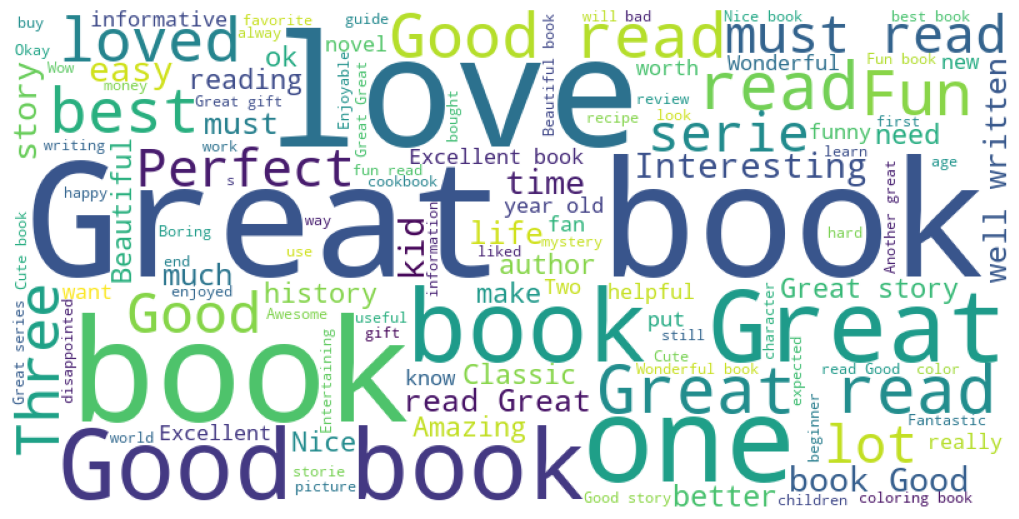

In [32]:
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.savefig(f'title_word_cloud.svg', format='svg')
plt.show()

In [33]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rutvikdhopate/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [34]:
from collections import Counter
import matplotlib.pyplot as plt
from nltk import bigrams
from nltk.tokenize import word_tokenize
import nltk

# Ensure NLTK resources are available
nltk.download('punkt')

def get_top_n_bigrams(text, n):
    """
    Extracts the top n bigrams from a given string.

    Parameters:
        text (str): Input string.
        n (int): Number of top bigrams to return.

    Returns:
        List[Tuple[str, int]]: List of tuples containing bigrams and their counts.
    """
    # Tokenize the text
    tokens = word_tokenize(text.lower())

    # Generate bigrams
    bigram_list = list(bigrams(tokens))

    # Count bigrams
    bigram_counts = Counter(bigram_list)

    # Get the top n bigrams
    return bigram_counts.most_common(n)

def plot_top_bigrams(bigrams_with_counts, title, filename):
    """
    Plots the top bigrams with their counts.

    Parameters:
        bigrams_with_counts (List[Tuple[str, int]]): List of bigrams with their counts.
    """
    bigrams, counts = zip(*bigrams_with_counts)
    bigram_labels = [' '.join(bigram) for bigram in bigrams]

    plt.figure(figsize=(15, 6))
    plt.bar(bigram_labels, counts, color='skyblue')
    plt.xlabel('Bigrams', fontsize=14)
    plt.ylabel('Counts', fontsize=14)
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{filename}.svg', format='svg')
    plt.show()


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rutvikdhopate/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Top Bigrams: [(('five', 'stars'), 107967), (('stars', 'five'), 66725), (('!', '!'), 30852), (('great', 'book'), 25912), (('this', 'book'), 24140), (('book', '!'), 19110), (('four', 'stars'), 18973), (('!', 'great'), 15044), (('of', 'the'), 14099), (('a', 'great'), 12287), ((',', 'but'), 11613), (('stars', 'four'), 11429), (('good', 'book'), 11259), (('book', 'for'), 10895), (('book', '.'), 10229), (('great', 'read'), 9428), (('love', 'this'), 8812), (('is', 'a'), 8474), (('!', 'a'), 8460), (('good', 'read'), 8416), (('a', 'good'), 8302), (('for', 'the'), 8231), (('read', '!'), 8202), (('this', 'is'), 8005), (('it', '!'), 7930), (('.', 'great'), 7898), (('love', 'it'), 7756), (('book', 'great'), 7602), (('three', 'stars'), 7371), (('in', 'the'), 7337), (('the', 'best'), 7022), (('it', "'s"), 6998), (('to', 'read'), 6865), (('one', 'of'), 6354), (('for', 'a'), 6188), (('.', 'a'), 6126), (('i', 'love'), 6090), (('if', 'you'), 6001), (('!', 'five'), 5994), (('loved', 'it'), 5978), (('stars

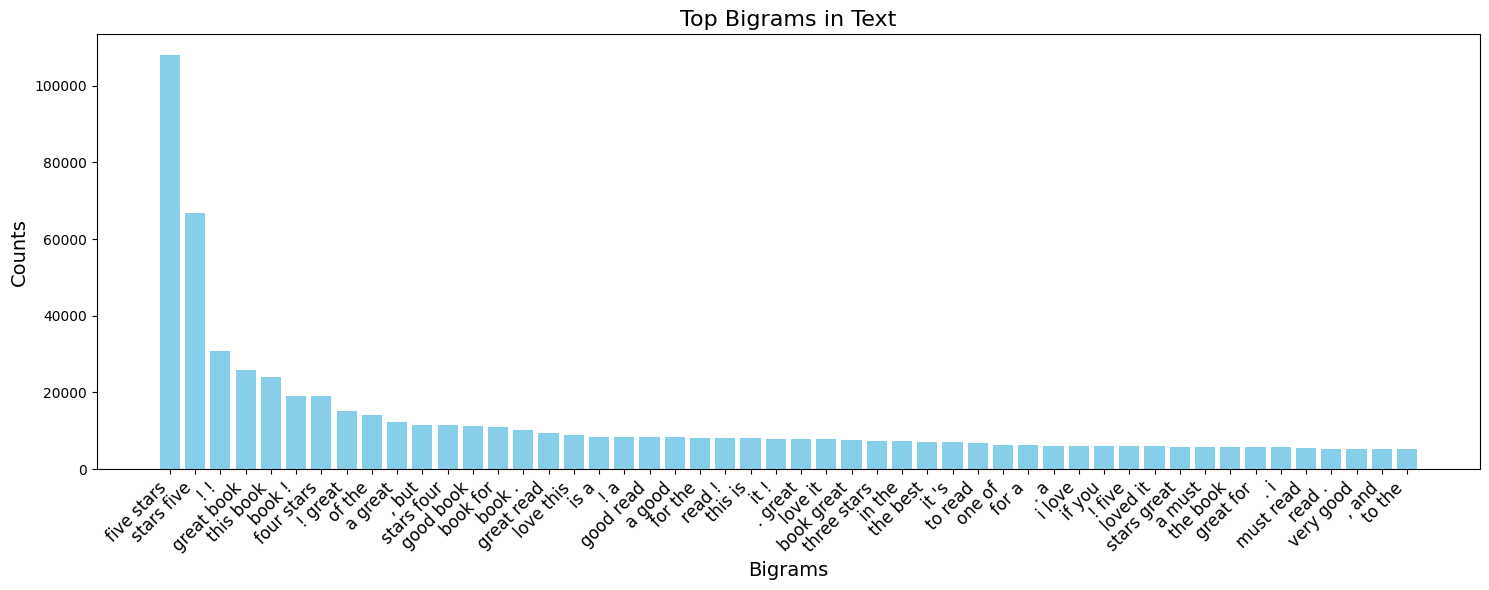

In [36]:
text = ' '.join(all_titles)
top_n = 50

# Get top n bigrams
top_bigrams = get_top_n_bigrams(text, top_n)
print("Top Bigrams:", top_bigrams)

# Plot the top bigrams
plot_top_bigrams(top_bigrams, title="Top Bigrams in Text", filename="bigrams_plot.png")

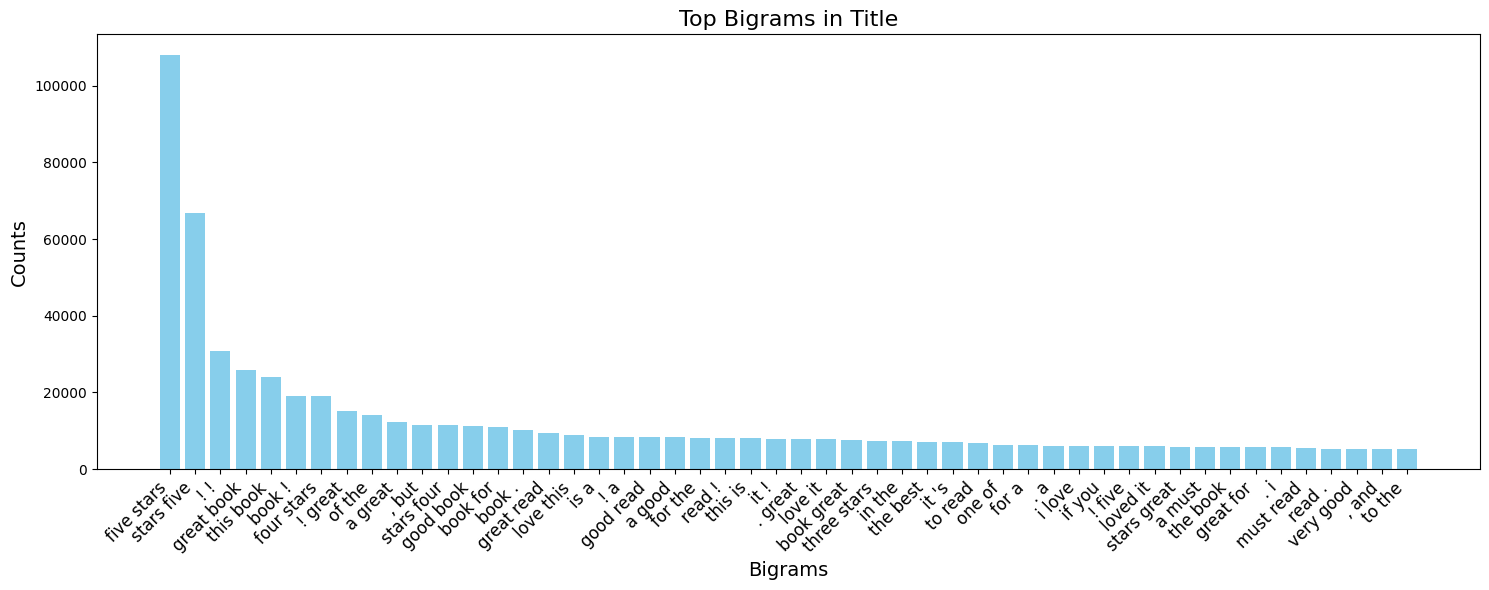

In [161]:
# Plot the top bigrams
plot_top_bigrams(top_bigrams, 'Top Bigrams in Title', 'title_bigrams')

In [163]:
one_two_star_titles = [sample_dataset[i]['title'] for i in range(len(sample_dataset)) if sample_dataset[i]['rating'] in [1, 2]]

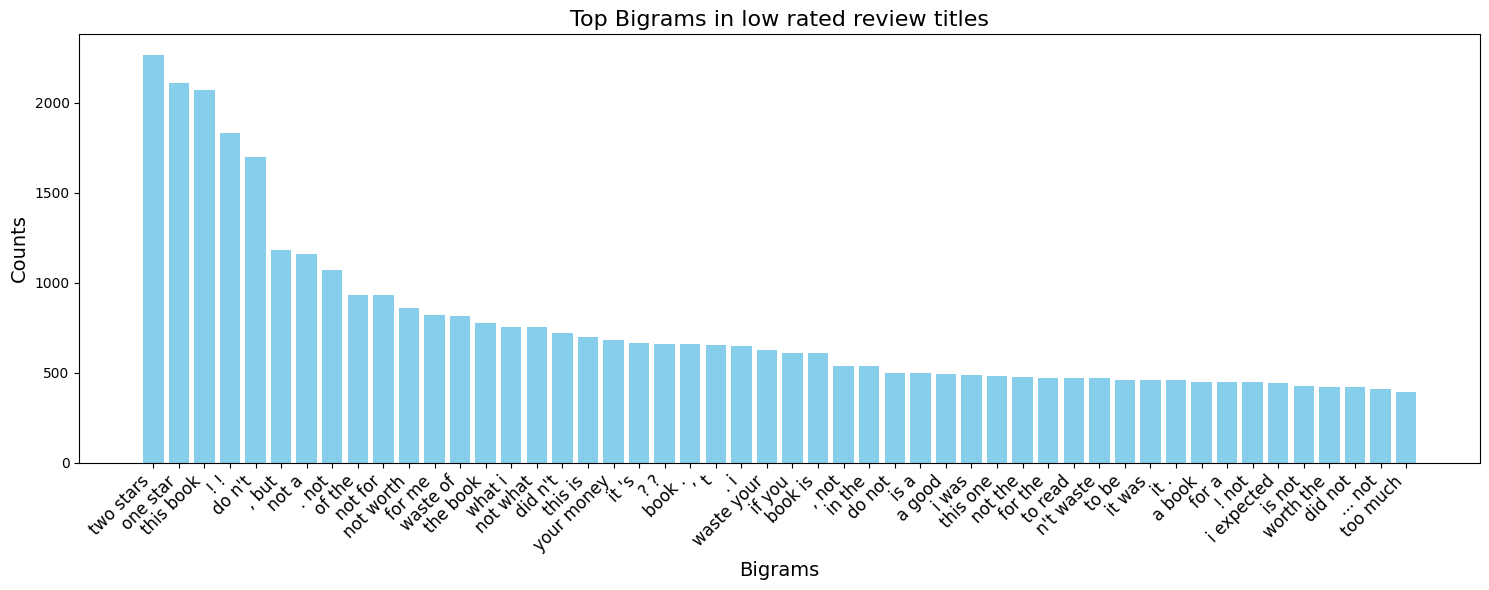

In [165]:
one_two_star_text = ' '.join(one_two_star_titles)
top_n = 50

# Get top n bigrams
one_two_star_top_bigrams = get_top_n_bigrams(one_two_star_text, top_n)

# Plot the top bigrams
plot_top_bigrams(one_two_star_top_bigrams, 'Top Bigrams in low rated review titles', 'one_two_stars_title_bigrams')

In [168]:
x = 100

In [222]:
x += 1
sample_dataset[x]

{'rating': 5.0,
 'title': 'This was a great used book purchase',
 'text': 'This was a great used book purchase. There are several patterns that I plan on knitting.  Great color pictures of completed items.',
 'images': [],
 'asin': '0312388098',
 'parent_asin': '0312388098',
 'user_id': 'AF5MJENGAL5G6BUFIVMH5LRSZ6EA',
 'timestamp': 1504193900779,
 'helpful_vote': 0,
 'verified_purchase': True}

In [223]:
from datetime import datetime

extracted_timestamps = [datetime.fromtimestamp(sample_dataset[i]['timestamp']/1000) for i in range(len(sample_dataset))]

In [235]:
# average rating over years
ratings_vs_year = {}
for key, value in zip(extracted_timestamps, ratings):
  ratings_vs_year.setdefault(key.year, []).append(value)

In [237]:
num_reviews_across_years = [len(i) for i in ratings_vs_year.values()]

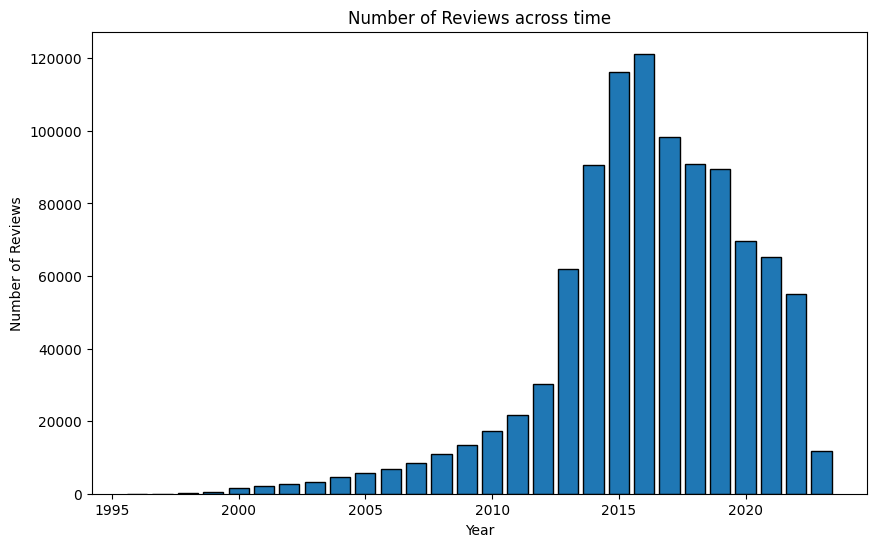

In [251]:
plt.figure(figsize=(10,6))
plt.bar(ratings_vs_year.keys(), num_reviews_across_years, edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.title('Number of Reviews across time')
plt.savefig('num_reviews_across_time.svg', format='svg')
plt.show()

In [ ]:
avg_rating_across_years = [np.mean(i) for i in ratings_vs_year.values()]
ratings_vs_year = dict(sorted(ratings_vs_year.items()))
print(ratings_vs_year.keys())

# The below graph - average rating over time - can be misleading because as we know that 5 star reviews are more common and the number of ratings over time has increased (atleast in our sub sample)

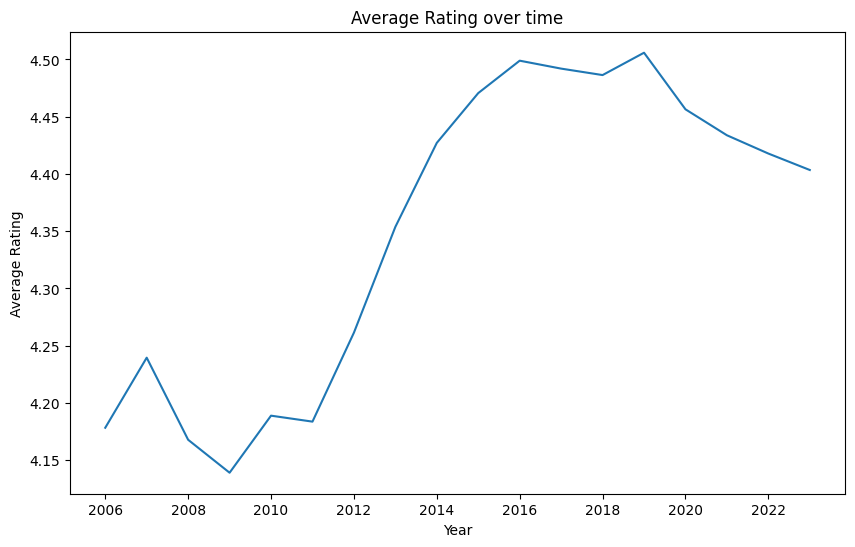

In [264]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(10,6))
plt.plot(list(ratings_vs_year.keys())[10:], avg_rating_across_years[10:])
ax = plt.gca()  # Get current axis
ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # Ensure integer ticks
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.title('Average Rating over time')
plt.savefig('avg_rating_over_time.svg', format='svg')
plt.show()

In [ ]:
ratings_vs_year

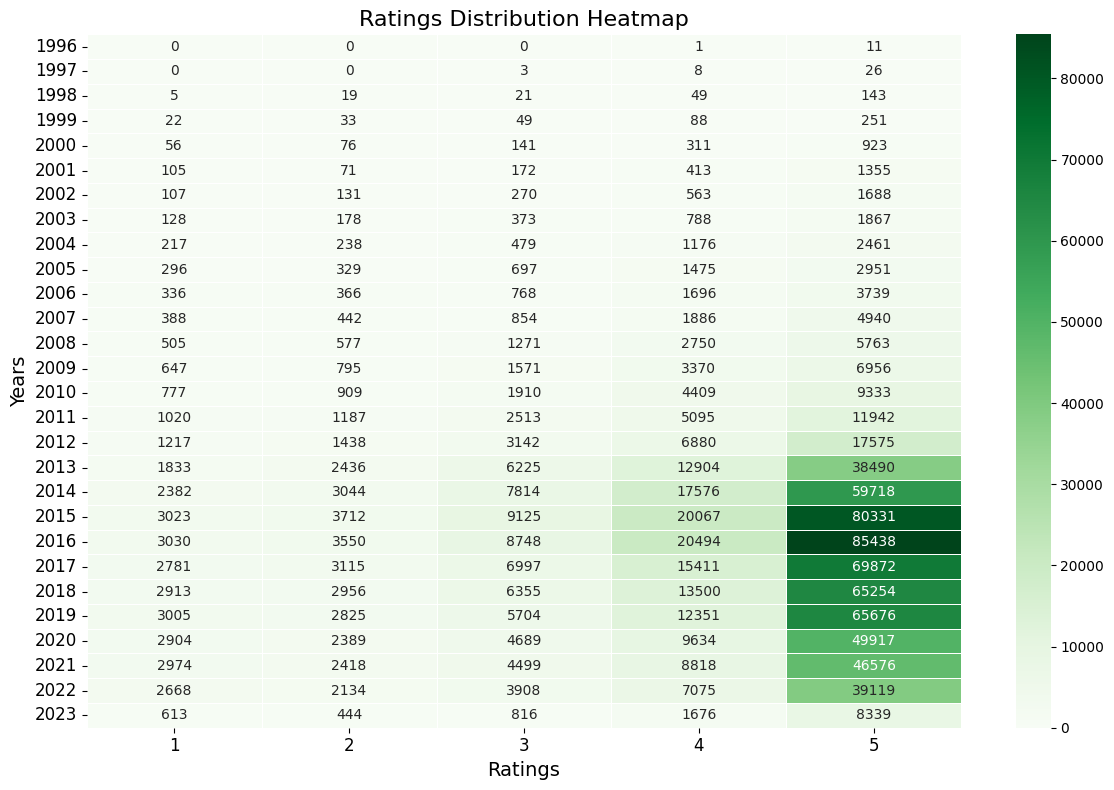

In [271]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Define the range of ratings to consider
rating_range = [1, 2, 3, 4, 5]

# Prepare the data for the heatmap
years = sorted(ratings_vs_year.keys())
heatmap_data = []

for year in years:
    # Count ratings for each year
    rating_counts = [ratings_vs_year[year].count(rating) for rating in rating_range]
    heatmap_data.append(rating_counts)

# Convert to a NumPy array for plotting
heatmap_data = np.array(heatmap_data)

# Create the heatmap
plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    heatmap_data,
    annot=True,         # Annotate with counts
    fmt="d",            # Integer formatting
    cmap="Greens",      # Green color gradient
    cbar=True,          # Show color bar
    xticklabels=rating_range,  # X-axis labels as ratings
    yticklabels=years,         # Y-axis labels as years
    linewidths=0.5,     # Line width for better separation
)

# Customize the plot
plt.title("Ratings Distribution Heatmap", fontsize=16)
plt.xlabel("Ratings", fontsize=14)
plt.ylabel("Years", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

In [275]:
ratings_vs_year.keys()

dict_keys([1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [276]:
def get_n_reviews_of_user(dataset, user_id, n):
  """
  Get n reviews of the specified user
  dataset - Huggingface dataset
  user_id - string
  n - int
  """
  user_reviews = []
  for i in range(len(dataset)):
    if len(user_reviews) >= n:
      break
    if dataset[i]['user_id'] == user_id:
      user_reviews.append(dataset[i])
  return user_reviews


In [ ]:
user_id = sample_dataset[15]['user_id']
user_review = get_n_reviews_of_user(sample_dataset, user_id, 8)
print(user_id, '\n')
for i in user_review:
  print(i['text'])
  print(i['asin'])
  print("="*10)

In [288]:
for i in user_review:
  print(i['text'])
  print(i['asin'])
  print("="*10)

Wonderful book but not crazy about using the word hate with the kids...too strong a word for the fun topic. We just read it and choose a different word to use in its place
0803736800
We love this book and the FOUND book also by Salina Yoon.
0802737803
I waned to like it but its just...  meh... not using it in my nursing. Have found better items. Will donate
1508558884
Sweet bookplates!
0735336296
Cute book! Not quite as good as the original but still a fun one to read at Christmastime, my kids enjoyed it.
0803729952
I bought two packs of postcards- thinking 60 would be plenty, but I have to tell you everyone that has seen them has asked if I have more?? They are all different book covers, so the variety is nice! Works as a cute gift too! Highly recommended.
0811849783
I bought these and the Nancy Drew postcards(also listed here on Amazon). My daughter wanted a ND party for her birthday and these work great as simple thank you cards! Super cute and sweet for anyone of any age! I am buyi

In [284]:
sample_dataset[0:20]

{'rating': [1.0,
  5.0,
  5.0,
  5.0,
  5.0,
  1.0,
  4.0,
  5.0,
  3.0,
  1.0,
  5.0,
  5.0,
  5.0,
  5.0,
  4.0,
  5.0,
  2.0,
  5.0,
  4.0,
  5.0],
 'title': ['Not a watercolor book! Seems like copies imo.',
  'Updated: after 1st arrived damaged this one is perfect',
  'Excellent! I love it!',
  'Updated after 1st arrived damaged. Excellent',
  'Beautiful patterns!',
  'Missing the sketch pad',
  'Beautiful, but should only be printed on 1 side imo.',
  'Bought for myself & I love it!',
  'Half the size of her other books, but same price! WTH?',
  'Crease down entire side of every page!!!',
  'Granddaughter loves it!',
  'Five Stars',
  'Five Stars',
  'Aweeeeesome.',
  "Wish they'd left hate out!",
  'Love it',
  'I waned to like it but its just',
  'Five Stars',
  'Not quite up to the original but still cute...',
  'Buy more than you need!'],
 'text': ['It is definitely not a watercolor book.  The paper bucked completely.  The pages honestly appear to be photo copies of other pict

[0, 1, 0, 0, 0, 0, 1, 0, 3, 2, 94, 0, 0, 58, 2, 0, 0, 0, 0, 1]
[1.0, 5.0, 5.0, 5.0, 5.0, 1.0, 4.0, 5.0, 3.0, 1.0, 5.0, 5.0, 5.0, 5.0, 4.0, 5.0, 2.0, 5.0, 4.0, 5.0]


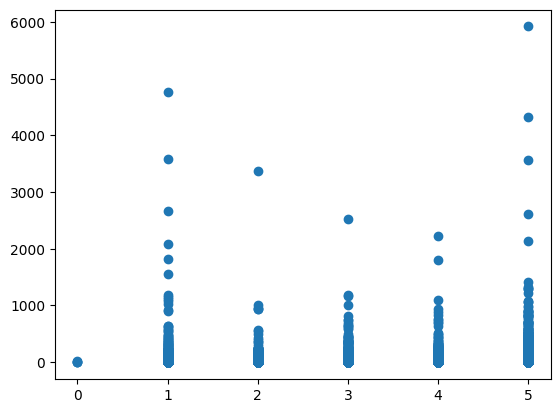

In [298]:
# helpful votes vs ratings - are high rated or low rated reviews more helpful than others
print(helpful_votes[0:20])
print(ratings[0:20])


plt.scatter(ratings, helpful_votes)
plt.show()

In [304]:
helpful_votes_gt_0 = []
ratings_helpful_votes_gt_0 = []

for index, votes in enumerate(helpful_votes):
  if votes > 0:
    helpful_votes_gt_0.append(votes)
    ratings_helpful_votes_gt_0.append(ratings[index])

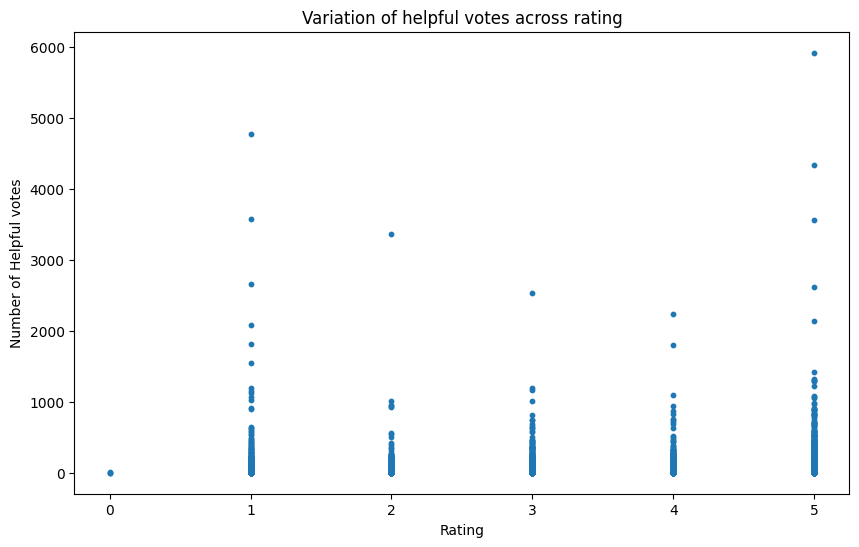

In [314]:
plt.figure(figsize=(10, 6))
plt.scatter(ratings_helpful_votes_gt_0, helpful_votes_gt_0, s=10)
plt.xlabel('Rating')
plt.ylabel('Number of Helpful votes')
plt.title('Variation of helpful votes across rating')
plt.savefig('helpful_votes_vs_rating.svg', format='svg')
plt.show()

In [302]:
# most helpful review in the sample dataset (the review is on a cookbook!)
sample_dataset[helpful_votes.index(max(helpful_votes))]

{'rating': 5.0,
 'title': 'The best official Instant Pot cookbook',
 'text': "If you were one of the lucky ones who bought an Instant Pot (aka IP) on Prime Day in July, like I did, congratulations. If you found, after taking it out of the box, that it's a little intimidating, join the club. There is definitely a learning curve with the IP but so worth the effort. I immediately went on the hunt for recipes to try and downloaded a bunch of *free* Instant Pot cookbooks. Let the buyer beware, *free* does not equal *good* - many of those books are poorly edited/translated and have serious errors.<br /><br />This is an 'official' Instant Pot cookbook and a very good one. I was warned that unless there is a picture of a real IP on the cover (copyright) it is not sanctioned by Instant Pot - this one is an official cookbook but it's so much more than just recipes. I usually purchase my books for Kindle (and there is an e-book version) but this one I bought in soft-back. For the price, under $10

In [292]:
sample_dataset[2]

{'rating': 5.0,
 'title': 'Excellent! I love it!',
 'text': 'I bought it for the bag on the front so it paid for itself with that imo.  I haven’t started anything yet from it bc I’m still busy with other projects, but I’m really looking forward to starting some.',
 'images': [],
 'asin': '1782490671',
 'parent_asin': '1782490671',
 'user_id': 'AFKZENTNBQ7A7V7UXW5JJI6UGRYQ',
 'timestamp': 1640383495102,
 'helpful_vote': 0,
 'verified_purchase': True}